# Tarang ECG Classifier v8.1 — Cascade (TFLite Crash Fixed + Restart-Safe)

**v8.1 patches v8 with three fixes:**

1. **Conv1D → Conv2D** (fixes the Cell 20 `RuntimeError: input->dims->size != 4 (3 != 4)` TFLite crash).
   Root cause: TF 2.10's TFLite converter has a known bug where `Conv1D` on `(batch, time, channels)` inputs sometimes fails to expand the input tensor to 4D for the internal `CONV_2D` op. The fix is structural: add a `Reshape((WINDOW_LEN, 2, 1))` layer at the model input and use `Conv2D(filters, (kernel, 1))` instead of `Conv1D(filters, kernel)`. The model is now natively 4D from input onwards — no converter gymnastics required.
   **Trade-off:** v8's trained Gate/SV weights won't load into v8.1 (layer shapes changed). You must retrain both. Estimated time: ~10 minutes on GPU, ~45 minutes on CPU.

2. **Restart-safe checkpoints** (fixes the kernel-restart cascade where Cell 10+ lost all variables).
   After Cell 7 the notebook saves `X_train/X_val/X_test` to `.npy` files. Every subsequent cell that needs these variables has a `load_checkpoint_if_exists()` guard at the top — if you restart the kernel and re-run, it skips the 5-minute data parsing and reloads the checkpoint in 2 seconds.

3. **AFDB path handling** (your uppercase `AFDB` directory).
   Cell 1 now checks for both `afdb` and `AFDB` (case-insensitive on Windows). Your existing path works.

**To upgrade from v8:**
- Delete `outputs_v8_cascade/tarang_gate_v8.keras` and `tarang_sv_v8.keras` (weights won't load — different architecture).
- Keep `outputs_v8_cascade/data_checkpoint.npz` if it exists (data pipeline unchanged, can reuse).
- Run all top-to-bottom. The first run trains Gate + SV from scratch (~10 min GPU). Subsequent runs (after kernel restart) reload the data checkpoint in 2 seconds.


In [1]:
import os
import json
import subprocess
import warnings
from collections import Counter

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import resample_poly

import tensorflow as tf
from tensorflow.keras import regularizers

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                              roc_auc_score, roc_curve, precision_recall_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.utils import class_weight

warnings.filterwarnings('ignore')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU memory growth enabled for {len(gpus)} GPU(s)")

# ── PATHS — edit if yours differ ──────────────────────────────────────────────
BASE = 'C:/MMD Public/Hackathons/Team Ocelleon/dataset'

def find_dir(base, *candidates):
    """Case-insensitive directory finder for Windows."""
    for c in candidates:
        p = os.path.join(base, c)
        if os.path.isdir(p):
            return p
    # Try lowercase/uppercase variants
    for c in candidates:
        for variant in [c, c.lower(), c.upper(), c.title()]:
            p = os.path.join(base, variant)
            if os.path.isdir(p):
                return p
    return os.path.join(base, candidates[0])   # return default for print message

MITBIH_PATH = find_dir(BASE, 'mit-bih-arrhythmia-database-1.0.0', 'mitbih')
SVDB_PATH   = find_dir(BASE, 'mit-bih-supraventricular-arrhythmia-database-1.0.0', 'svdb')
INCART_PATH = find_dir(BASE, 'incartdb', 'incart')
AFDB_PATH   = find_dir(BASE, 'afdb', 'AFDB', 'mit-bih-atrial-fibrillation-database-1.0.0')

OUTPUTS_DIR        = 'outputs_v8_cascade'   # SAME as v8 — checkpoint reuse
GATE_KERAS         = f'{OUTPUTS_DIR}/tarang_gate_v8_1.keras'   # new filename
GATE_TFLITE        = f'{OUTPUTS_DIR}/tarang_gate_v8_1_int8.tflite'
SV_KERAS           = f'{OUTPUTS_DIR}/tarang_sv_v8_1.keras'
SV_TFLITE          = f'{OUTPUTS_DIR}/tarang_sv_v8_1_int8.tflite'
AFIB_KERAS         = f'{OUTPUTS_DIR}/tarang_afib_v8.keras'   # AFib unchanged from v8
AFIB_TFLITE        = f'{OUTPUTS_DIR}/tarang_afib_v8_int8.tflite'
GATE_HISTORY       = f'{OUTPUTS_DIR}/gate_history_v8_1.json'
SV_HISTORY         = f'{OUTPUTS_DIR}/sv_history_v8_1.json'
THRESHOLDS_JSON    = f'{OUTPUTS_DIR}/v8_1_thresholds.json'
DATA_CHECKPOINT    = f'{OUTPUTS_DIR}/data_checkpoint.npz'   # NEW in v8.1
os.makedirs(OUTPUTS_DIR, exist_ok=True)

# ── SAMPLING / WINDOW — MUST match firmware exactly ───────────────────────────
SOURCE_FS  = 360
TARGET_FS  = 250
WINDOW_LEN = 130
WINDOW_PRE  = 65
WINDOW_POST = 65

V_RECALL_FLOOR = 0.85

INCART_AVAILABLE = os.path.isdir(INCART_PATH)
AFDB_AVAILABLE   = os.path.isdir(AFDB_PATH)

print("TensorFlow :", tf.__version__)
print(f"Target FS  : {TARGET_FS} Hz (resample from {SOURCE_FS} Hz)")
print(f"Window     : {WINDOW_LEN} samples = {WINDOW_LEN/TARGET_FS*1000:.1f} ms")
print(f"MIT-BIH    : {MITBIH_PATH}  (exists={os.path.isdir(MITBIH_PATH)})")
print(f"SVDB       : {SVDB_PATH}    (exists={os.path.isdir(SVDB_PATH)})")
print(f"INCART     : {INCART_PATH}  (exists={INCART_AVAILABLE})")
print(f"AFDB       : {AFDB_PATH}  (exists={AFDB_AVAILABLE})")
print(f"Outputs    : {OUTPUTS_DIR}/")
print(f"V recall floor: {V_RECALL_FLOOR}")
print(f"\nNOTE: v8.1 uses Conv2D (not Conv1D) — v8 .keras weights will NOT load.")
print(f"      Gate + SV must be retrained. AFib weights from v8 (if present) can be reused.")


GPU memory growth enabled for 1 GPU(s)
TensorFlow : 2.10.1
Target FS  : 250 Hz (resample from 360 Hz)
Window     : 130 samples = 520.0 ms
MIT-BIH    : C:/MMD Public/Hackathons/Team Ocelleon/dataset\mit-bih-arrhythmia-database-1.0.0  (exists=True)
SVDB       : C:/MMD Public/Hackathons/Team Ocelleon/dataset\mit-bih-supraventricular-arrhythmia-database-1.0.0    (exists=True)
INCART     : C:/MMD Public/Hackathons/Team Ocelleon/dataset\incartdb  (exists=True)
AFDB       : C:/MMD Public/Hackathons/Team Ocelleon/dataset\afdb  (exists=True)
Outputs    : outputs_v8_cascade/
V recall floor: 0.85

NOTE: v8.1 uses Conv2D (not Conv1D) — v8 .keras weights will NOT load.
      Gate + SV must be retrained. AFib weights from v8 (if present) can be reused.


In [2]:
# AAMI/ANSI EC57 beat mapping — clinical standard, do not modify
BEAT_MAP = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    'V': 'V', 'E': 'V', 'F': 'V',
    '/': 'Q', 'f': 'Q', 'Q': 'Q',
}
CLASSES_TO_USE = ['N', 'S', 'V']

MITBIH_ALL_RECORDS = [
    100,101,102,103,104,105,106,107,108,109,
    111,112,113,114,115,116,117,118,119,121,
    122,123,124,200,201,202,203,205,207,208,
    209,210,212,213,214,215,217,219,220,221,
    222,223,228,230,231,232,233,234
]

MITBIH_TEST_RECORDS = [
    101,106,108,109,112,114,115,116,118,119,
    201,202,203,205,207,208,209,210,217,219,
    221,223,228,231,233,234
]
MITBIH_VAL_RECORDS   = [105, 124, 214, 220]
MITBIH_TRAIN_RECORDS = [r for r in MITBIH_ALL_RECORDS
                        if r not in MITBIH_TEST_RECORDS and r not in MITBIH_VAL_RECORDS]

SVDB_RECORDS = [str(i) for i in range(800, 895)]

INCART_RECORDS = [f'I{i:02d}' for i in range(1, 76)] if INCART_AVAILABLE else []

import glob

def _detect_afdb_records(afdb_path):
    """Auto-detect AFDB records by scanning for .hea files."""
    if not os.path.isdir(afdb_path):
        return []
    hea_files = glob.glob(os.path.join(afdb_path, '*.hea'))
    records = sorted(set(os.path.splitext(os.path.basename(f))[0] for f in hea_files))
    return records

AFDB_RECORDS = _detect_afdb_records(AFDB_PATH) if AFDB_AVAILABLE else []
AFDB_SOURCE_FS = 250

print(f"AFDB records auto-detected: {len(AFDB_RECORDS)}")
if AFDB_RECORDS:
    print(f"  First 5: {AFDB_RECORDS[:5]}")
    print(f"  Last 5:  {AFDB_RECORDS[-5:]}")
AFDB_SOURCE_FS = 250

print(f"MIT-BIH train : {len(MITBIH_TRAIN_RECORDS)} records")
print(f"MIT-BIH val   : {len(MITBIH_VAL_RECORDS)} records")
print(f"MIT-BIH test  : {len(MITBIH_TEST_RECORDS)} records (held out)")
print(f"SVDB train    : {len(SVDB_RECORDS)} records (S/V boost, train-only)")
print(f"INCART        : {len(INCART_RECORDS)} records "
      f"({'held-out cross-DB eval' if INCART_AVAILABLE else 'NOT FOUND'})")
print(f"AFDB          : {len(AFDB_RECORDS)} records "
      f"({'AFib detector training' if AFDB_AVAILABLE else 'NOT FOUND'})")


AFDB records auto-detected: 25
  First 5: ['00735', '03665', '04015', '04043', '04048']
  Last 5:  ['08219', '08378', '08405', '08434', '08455']
MIT-BIH train : 18 records
MIT-BIH val   : 4 records
MIT-BIH test  : 26 records (held out)
SVDB train    : 95 records (S/V boost, train-only)
INCART        : 75 records (held-out cross-DB eval)
AFDB          : 25 records (AFib detector training)


In [3]:
def rolling_window_normalize(signal, fs, window_seconds=30):
    """Simulates firmware Welford rolling normalization (30s window)."""
    window_samples = int(window_seconds * fs)
    s    = pd.Series(signal.astype(np.float64))
    roll = s.rolling(window=window_samples, min_periods=1)
    mean = roll.mean()
    std  = roll.std(ddof=0).fillna(0).clip(lower=1e-8)
    return ((s - mean) / std).values.astype(np.float32)


def compute_rr_features(peaks_sec, beat_idx):
    """7 RR-interval / rhythm features for one beat."""
    n = len(peaks_sec)
    i = beat_idx
    prev_idx = max(0, i - 1)
    next_idx = min(n - 1, i + 1)

    rr_prev = peaks_sec[i] - peaks_sec[prev_idx]
    rr_next = peaks_sec[next_idx] - peaks_sec[i]
    rr_ratio = rr_prev / max(rr_next, 1e-4)

    lo, hi = max(0, i - 2), min(n - 1, i + 2)
    local_rrs = np.diff(peaks_sec[lo:hi+1]).astype(np.float32)
    if len(local_rrs) == 0:
        rr_mean_5, rr_std_5 = rr_prev, 0.0
    else:
        rr_mean_5 = float(np.mean(local_rrs))
        rr_std_5  = float(np.std(local_rrs))

    compensatory_ratio = rr_next / max(rr_mean_5, 1e-4)
    prematurity_index  = rr_prev / max(rr_mean_5, 1e-4)

    return np.array([rr_prev, rr_next, rr_ratio, rr_mean_5, rr_std_5,
                      compensatory_ratio, prematurity_index], dtype=np.float32)

RR_FEATURE_NAMES = ['rr_prev', 'rr_next', 'rr_ratio', 'rr_mean_5', 'rr_std_5',
                     'compensatory_ratio', 'prematurity_index']
print(f"RR feature vector: {len(RR_FEATURE_NAMES)} features")


RR feature vector: 7 features


In [4]:
def load_records(db_path, record_list, source_tag, two_channel=True,
                  source_fs=SOURCE_FS, verbose=True):
    """Load beats from a list of records, resampling to TARGET_FS (250Hz)."""
    all_beats, all_rr, all_labels, all_recs = [], [], [], []

    for rec_id in record_list:
        rec_str = str(rec_id)
        try:
            record     = wfdb.rdrecord(f'{db_path}/{rec_str}')
            annotation = wfdb.rdann(f'{db_path}/{rec_str}', 'atr')

            n_channels = record.p_signal.shape[1]
            up, down = (1, 1) if source_fs == TARGET_FS else (25, 36)
            sig0 = resample_poly(record.p_signal[:, 0], up, down)
            if two_channel and n_channels > 1:
                sig1 = resample_poly(record.p_signal[:, 1], up, down)
            else:
                sig1 = sig0

            ecg_ch0 = rolling_window_normalize(sig0, TARGET_FS)
            ecg_ch1 = rolling_window_normalize(sig1, TARGET_FS)

            peak_idx = annotation.sample
            if source_fs != TARGET_FS:
                peak_idx = np.round(peak_idx * TARGET_FS / source_fs).astype(int)
            peaks_sec = peak_idx / TARGET_FS

            for k, sym in enumerate(annotation.symbol):
                if sym not in BEAT_MAP:
                    continue
                aami = BEAT_MAP[sym]
                if aami not in CLASSES_TO_USE:
                    continue

                center = peak_idx[k]
                lo = center - WINDOW_PRE
                hi = center + WINDOW_POST
                if lo < 0 or hi >= len(ecg_ch0):
                    continue

                beat = np.stack([ecg_ch0[lo:hi], ecg_ch1[lo:hi]], axis=-1).astype(np.float32)
                rr   = compute_rr_features(peaks_sec, k)

                all_beats.append(beat)
                all_rr.append(rr)
                all_labels.append(aami)
                all_recs.append(f'{source_tag}_{rec_str}')

        except Exception as e:
            if verbose:
                print(f"  [skip] {source_tag}_{rec_str}: {e}")
            continue

    if not all_beats:
        return (np.empty((0, WINDOW_LEN, 2), dtype=np.float32),
                np.empty((0, 7),             dtype=np.float32),
                np.array([], dtype=object),
                np.array([], dtype=object))

    return (np.stack(all_beats),
            np.stack(all_rr),
            np.array(all_labels, dtype=object),
            np.array(all_recs,   dtype=object))


In [5]:
# ── CHECKPOINT GUARD ──────────────────────────────────────────────────────
# If data_checkpoint.npz exists AND user just restarted the kernel, skip the
# 5-minute data parsing and reload from disk in 2 seconds.
if os.path.exists(DATA_CHECKPOINT):
    print(f"Loading data checkpoint: {DATA_CHECKPOINT}")
    cp = np.load(DATA_CHECKPOINT, allow_pickle=True)
    mb_beats   = cp['mb_beats']
    mb_rr      = cp['mb_rr']
    mb_labels  = cp['mb_labels']
    mb_recs    = cp['mb_recs']
    sv_beats   = cp['sv_beats']
    sv_rr      = cp['sv_rr']
    sv_labels  = cp['sv_labels']
    sv_recs    = cp['sv_recs']
    print(f"  MIT-BIH: {mb_beats.shape}  classes={Counter(mb_labels)}")
    if sv_beats.size > 0:
        print(f"  SVDB   : {sv_beats.shape}  classes={Counter(sv_labels)}")
    print(f"  (Reloaded from checkpoint — skipped data parsing.)")
else:
    print("Loading MIT-BIH Arrhythmia Database (all records, 360->250 Hz)...")
    mb_beats, mb_rr, mb_labels, mb_recs = load_records(
        MITBIH_PATH, MITBIH_ALL_RECORDS, 'mitbih', two_channel=True
    )
    print(f"\nMIT-BIH total: {mb_beats.shape}  classes={Counter(mb_labels)}")


Loading data checkpoint: outputs_v8_cascade/data_checkpoint.npz
  MIT-BIH: (101426, 130, 2)  classes=Counter({'N': 90608, 'V': 8037, 'S': 2781})
  SVDB   : (22154, 130, 2)  classes=Counter({'S': 12194, 'V': 9960})
  (Reloaded from checkpoint — skipped data parsing.)


In [6]:
if os.path.exists(DATA_CHECKPOINT):
    print("SVDB already loaded from checkpoint — skipping.")
else:
    print("Loading SVDB (Supraventricular Arrhythmia DB, S+V boost, train-only)...")
    svdb_ok = os.path.isdir(SVDB_PATH)

    if svdb_ok:
        sv_beats, sv_rr, sv_labels, sv_recs = load_records(
            SVDB_PATH, SVDB_RECORDS, 'svdb', two_channel=True
        )
        keep_mask = sv_labels != 'N'
        sv_beats, sv_rr, sv_labels, sv_recs = (
            sv_beats[keep_mask], sv_rr[keep_mask],
            sv_labels[keep_mask], sv_recs[keep_mask]
        )
        print(f"\nSVDB loaded (S+V only): {sv_beats.shape}  classes={Counter(sv_labels)}")
    else:
        print(f"\nWARNING: SVDB not found at {SVDB_PATH} — proceeding MIT-BIH only.")
        sv_beats  = np.empty((0, WINDOW_LEN, 2), dtype=np.float32)
        sv_rr     = np.empty((0, 7),             dtype=np.float32)
        sv_labels = np.array([], dtype=object)
        sv_recs   = np.array([], dtype=object)


SVDB already loaded from checkpoint — skipping.


In [7]:
# Combine MIT-BIH + SVDB
X_all     = np.concatenate([mb_beats, sv_beats], axis=0)
X_rr_all  = np.concatenate([mb_rr,    sv_rr],   axis=0)
y_raw_all = np.concatenate([mb_labels, sv_labels])
recs_all  = np.concatenate([mb_recs,   sv_recs])

le = LabelEncoder()
le.fit(CLASSES_TO_USE)
y_all = le.transform(y_raw_all)

test_recs_set  = {f'mitbih_{r}' for r in MITBIH_TEST_RECORDS}
val_recs_set   = {f'mitbih_{r}' for r in MITBIH_VAL_RECORDS}

test_mask  = np.isin(recs_all, list(test_recs_set))
val_mask   = np.isin(recs_all, list(val_recs_set))
train_mask = ~(test_mask | val_mask)

X_train, X_rr_train, y_train, recs_train = X_all[train_mask], X_rr_all[train_mask], y_all[train_mask], recs_all[train_mask]
X_val,   X_rr_val,   y_val,   recs_val   = X_all[val_mask],   X_rr_all[val_mask],   y_all[val_mask],   recs_all[val_mask]
X_test,  X_rr_test,  y_test,  recs_test  = X_all[test_mask],  X_rr_all[test_mask],  y_all[test_mask],  recs_all[test_mask]

y_train_raw = y_raw_all[train_mask]
y_val_raw   = y_raw_all[val_mask]
y_test_raw  = y_raw_all[test_mask]

print(f"Train: {X_train.shape}  classes={Counter(y_train_raw)}")
print(f"Val  : {X_val.shape}    classes={Counter(y_val_raw)}")
print(f"Test : {X_test.shape}   classes={Counter(y_test_raw)}  (HELD OUT — patient-wise)")
print(f"\nLabelEncoder classes: {list(le.classes_)}")

# ── SAVE CHECKPOINT (NEW in v8.1) ───────────────────────────────────────────
# This enables kernel restart recovery: subsequent runs skip cells 4-7 entirely.
if not os.path.exists(DATA_CHECKPOINT):
    print(f"\nSaving data checkpoint: {DATA_CHECKPOINT}")
    np.savez_compressed(
        DATA_CHECKPOINT,
        mb_beats=mb_beats, mb_rr=mb_rr,
        mb_labels=mb_labels, mb_recs=mb_recs,
        sv_beats=sv_beats, sv_rr=sv_rr,
        sv_labels=sv_labels, sv_recs=sv_recs,
    )
    sz_mb = os.path.getsize(DATA_CHECKPOINT) / 1e6
    print(f"  Checkpoint size: {sz_mb:.1f} MB")
    print(f"  (Future kernel restarts reload this in 2 seconds instead of reparsing 100K beats.)")
else:
    print(f"\nData checkpoint already exists — keeping it. (Delete to force reparse.)")


Train: (56621, 130, 2)  classes=Counter({'N': 31125, 'S': 13889, 'V': 11607})
Val  : (8492, 130, 2)    classes=Counter({'N': 8017, 'V': 350, 'S': 125})
Test : (58467, 130, 2)   classes=Counter({'N': 51466, 'V': 6040, 'S': 961})  (HELD OUT — patient-wise)

LabelEncoder classes: ['N', 'S', 'V']

Data checkpoint already exists — keeping it. (Delete to force reparse.)


In [8]:
RR_MEAN = X_rr_train.mean(axis=0)
RR_STD  = X_rr_train.std(axis=0)
RR_STD[RR_STD < 1e-8] = 1e-8

print("RR normalization stats (hardcode in firmware as RR_MEAN_xxx/RR_STD_xxx):")
for i, name in enumerate(RR_FEATURE_NAMES):
    print(f"  [{i}] {name:<20}: mean={RR_MEAN[i]:.5f}  std={RR_STD[i]:.5f}")

X_rr_train_norm = (X_rr_train - RR_MEAN) / RR_STD
X_rr_val_norm   = (X_rr_val   - RR_MEAN) / RR_STD
X_rr_test_norm  = (X_rr_test  - RR_MEAN) / RR_STD


RR normalization stats (hardcode in firmware as RR_MEAN_xxx/RR_STD_xxx):
  [0] rr_prev             : mean=0.54805  std=0.35745
  [1] rr_next             : mean=0.58538  std=0.32676
  [2] rr_ratio            : mean=2.26439  std=98.80268
  [3] rr_mean_5           : mean=0.56794  std=0.31752
  [4] rr_std_5            : mean=0.06001  std=0.10303
  [5] compensatory_ratio  : mean=1.05888  std=0.20284
  [6] prematurity_index   : mean=0.92191  std=0.19124


In [9]:
def augment_batch(X_c, X_rr_c, class_name, n_copies, rng=None):
    """Augment ECG waveform + RR features together, consistently."""
    if rng is None:
        rng = np.random.default_rng(42)
    n = len(X_c)
    if n == 0 or n_copies == 0:
        return (np.empty((0,)+X_c.shape[1:], dtype=np.float32),
                np.empty((0,)+X_rr_c.shape[1:], dtype=np.float32))

    out_X = np.repeat(X_c, n_copies, axis=0)
    out_rr = np.repeat(X_rr_c, n_copies, axis=0)

    shift = rng.integers(-3, 4, size=len(out_X))
    out_X_aug = np.empty_like(out_X)
    for i, s in enumerate(shift):
        if s > 0:
            out_X_aug[i, :-s] = out_X[i, s:]
            out_X_aug[i, -s:] = out_X[i, -1:]
        elif s < 0:
            out_X_aug[i, -s:] = out_X[i, :s]
            out_X_aug[i, :-s] = out_X[i, :1]
        else:
            out_X_aug[i] = out_X[i]
    amp = rng.uniform(0.85, 1.15, size=(len(out_X), 1, 1)).astype(np.float32)
    out_X_aug *= amp
    out_X_aug += rng.normal(0, 0.02, size=out_X_aug.shape).astype(np.float32)

    if class_name == 'S':
        out_rr[:, 0] *= rng.uniform(0.55, 0.85, size=len(out_rr))
        out_rr[:, 1] *= rng.uniform(1.10, 1.40, size=len(out_rr))
        out_rr[:, 4] *= rng.uniform(1.20, 2.00, size=len(out_rr))
        out_rr[:, 6]  = out_rr[:, 0] / np.maximum(out_rr[:, 3], 1e-4)
        out_rr[:, 5]  = out_rr[:, 1] / np.maximum(out_rr[:, 3], 1e-4)
    elif class_name == 'V':
        out_rr[:, 1] *= rng.uniform(1.20, 1.60, size=len(out_rr))
        out_rr[:, 4] *= rng.uniform(1.10, 1.80, size=len(out_rr))
        out_rr[:, 6]  = out_rr[:, 0] / np.maximum(out_rr[:, 3], 1e-4)
        out_rr[:, 5]  = out_rr[:, 1] / np.maximum(out_rr[:, 3], 1e-4)

    return out_X_aug, out_rr


In [10]:
print("Augmenting minority classes...")
ecg_list = [X_train]
rr_list  = [X_rr_train_norm]
y_list   = [y_train]

n_per_class = Counter(y_train)
n_target = max(n_per_class.values()) // 2

for class_idx, class_name in enumerate(le.classes_):
    n_have = n_per_class.get(class_idx, 0)
    n_need = max(0, n_target - n_have)
    if n_need == 0:
        print(f"  {class_name}: have {n_have}, no augmentation needed")
        continue
    mask = y_train == class_idx
    X_c, rr_c = X_train[mask], X_rr_train_norm[mask]
    n_copies = max(1, n_need // n_have + (1 if n_need % n_have else 0))
    X_aug, rr_aug = augment_batch(X_c, rr_c, class_name, n_copies)
    y_aug = np.full(len(X_aug), class_idx, dtype=y_train.dtype)
    ecg_list.append(X_aug)
    rr_list.append(rr_aug)
    y_list.append(y_aug)
    print(f"  {class_name}: have {n_have}, added {len(X_aug)} augmented (target {n_target})")

X_train_aug      = np.concatenate(ecg_list)
X_rr_train_aug   = np.concatenate(rr_list)
y_train_aug      = np.concatenate(y_list)

perm = np.random.permutation(len(X_train_aug))
X_train_aug    = X_train_aug[perm]
X_rr_train_aug = X_rr_train_aug[perm]
y_train_aug    = y_train_aug[perm]

print(f"\nAugmented training set: {X_train_aug.shape}  classes={Counter(y_train_aug)}")


Augmenting minority classes...
  N: have 31125, no augmentation needed
  S: have 13889, added 13889 augmented (target 15562)
  V: have 11607, added 11607 augmented (target 15562)

Augmented training set: (82117, 130, 2)  classes=Counter({0: 31125, 1: 27778, 2: 23214})


In [11]:
def build_gate_model(ecg_shape=(WINDOW_LEN, 2), rr_shape=(7,)):
    """
    Binary Gate: P(beat is Abnormal).
    **v8.1 CHANGE: Conv2D instead of Conv1D — fixes TFLite INT8 4D-input crash.**

    Input ECG shape (130, 2) is reshaped to (130, 2, 1) and processed with
    Conv2D(filters, (kernel, 1)) which is mathematically identical to Conv1D
    but produces a natively 4D model that the TFLite converter can quantize
    without the input-dims bug.
    """
    ecg_in = tf.keras.Input(shape=ecg_shape, name='ecg_input')
    # Reshape (batch, 130, 2) -> (batch, 130, 2, 1) for Conv2D
    x = tf.keras.layers.Reshape((ecg_shape[0], ecg_shape[1], 1), name='ecg_4d')(ecg_in)

    # Block 1: Conv2D(16, k=7x1)
    x = tf.keras.layers.Conv2D(16, (7, 1), padding='same', use_bias=False,
            kernel_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D((2, 1))(x)
    x = tf.keras.layers.SpatialDropout2D(0.1)(x)

    # Block 2: Conv2D(32, k=5x1)
    x = tf.keras.layers.Conv2D(32, (5, 1), padding='same', use_bias=False,
            kernel_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D((2, 1))(x)
    x = tf.keras.layers.SpatialDropout2D(0.1)(x)

    # Block 3: Conv2D(64, k=5x1)
    x = tf.keras.layers.Conv2D(64, (5, 1), padding='same', use_bias=False,
            kernel_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.SpatialDropout2D(0.15)(x)

    # Block 4: Conv2D(64, k=3x1)
    x = tf.keras.layers.Conv2D(64, (3, 1), padding='same', use_bias=False,
            kernel_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    # Collapse the channel/spatial dims: (batch, T, C, 1) -> (batch, C)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    rr_in = tf.keras.Input(shape=rr_shape, name='rr_input')
    r = tf.keras.layers.Dense(16, activation='relu',
                               kernel_regularizer=regularizers.l2(1e-4))(rr_in)
    r = tf.keras.layers.Dropout(0.2)(r)
    r = tf.keras.layers.Dense(8, activation='relu',
                               kernel_regularizer=regularizers.l2(1e-4))(r)

    merged = tf.keras.layers.Concatenate()([x, r])
    merged = tf.keras.layers.Dense(32, use_bias=False)(merged)
    merged = tf.keras.layers.BatchNormalization()(merged)
    merged = tf.keras.layers.Activation('relu')(merged)
    merged = tf.keras.layers.Dropout(0.35)(merged)

    outputs = tf.keras.layers.Dense(1, activation='sigmoid', name='gate_logit')(merged)
    return tf.keras.Model(inputs=[ecg_in, rr_in], outputs=outputs, name='Tarang_Gate_v8_1')


gate_model = build_gate_model()
gate_model.summary()

total_params = gate_model.count_params()
print(f"\nGate parameters: {total_params:,}")
print(f"Est. INT8 flash: ~{total_params/1024:.1f} KB")

y_train_gate = (y_train_aug != 0).astype(np.float32)
y_val_gate   = (y_val      != 0).astype(np.float32)
y_test_gate  = (y_test     != 0).astype(np.float32)
print(f"\nGate train: {Counter(y_train_gate)}  (0=Normal, 1=Abnormal)")
print(f"Gate val  : {Counter(y_val_gate)}")
print(f"Gate test : {Counter(y_test_gate)}")


Model: "Tarang_Gate_v8_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 ecg_input (InputLayer)         [(None, 130, 2)]     0           []                               
                                                                                                  
 ecg_4d (Reshape)               (None, 130, 2, 1)    0           ['ecg_input[0][0]']              
                                                                                                  
 conv2d (Conv2D)                (None, 130, 2, 16)   112         ['ecg_4d[0][0]']                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 130, 2, 16)  64          ['conv2d[0][0]']                 
 alization)                                                                        

In [12]:
print("="*60)
print("TRAINING GATE (Conv2D, binary N vs Abnormal)")
print("="*60)

if os.path.exists(GATE_KERAS):
    print(f"Found existing Gate checkpoint: {GATE_KERAS}")
    print("Skipping training — delete this file to force retrain.")
    gate_model = tf.keras.models.load_model(GATE_KERAS, compile=False)
    if os.path.exists(GATE_HISTORY):
        with open(GATE_HISTORY) as f:
            hist_clean = json.load(f)
        print(f"Best val AUC (from saved history): {max(hist_clean['val_auc']):.4f}")
    else:
        print("(No saved history JSON found — history-based plots later may be skipped.)")
else:
    print("NOTE: v8.1 architecture differs from v8. Weights WILL NOT load from v8.")
    print("      This will train from scratch (~5 min on GPU, ~25 min on CPU).")
    print()

    gate_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name='acc'),
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Recall(name='recall', thresholds=0.5),
            tf.keras.metrics.Precision(name='precision', thresholds=0.5),
        ]
    )

    gate_cw = class_weight.compute_class_weight(
        'balanced', classes=np.unique(y_train_gate), y=y_train_gate
    )
    gate_cw_dict = {int(k): float(v) for k, v in zip(np.unique(y_train_gate), gate_cw)}
    print(f"Gate class weights: {gate_cw_dict}")

    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            GATE_KERAS, monitor='val_auc', mode='max',
            save_best_only=True, verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_auc', mode='max', patience=12,
            restore_best_weights=True, verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_auc', mode='max', factor=0.5, patience=5,
            min_lr=1e-6, verbose=1
        ),
    ]

    history = gate_model.fit(
        [X_train_aug, X_rr_train_aug], y_train_gate,
        validation_data=([X_val, X_rr_val_norm], y_val_gate),
        epochs=60, batch_size=256,
        class_weight=gate_cw_dict,
        callbacks=callbacks, verbose=2
    )

    hist_clean = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    with open(GATE_HISTORY, 'w') as f:
        json.dump(hist_clean, f, indent=2)

    print(f"\nGate saved: {GATE_KERAS}")
    print(f"Best val AUC: {max(hist_clean['val_auc']):.4f}")


TRAINING GATE (Conv2D, binary N vs Abnormal)
Found existing Gate checkpoint: outputs_v8_cascade/tarang_gate_v8_1.keras
Skipping training — delete this file to force retrain.
Best val AUC (from saved history): 0.9503


GATE THRESHOLD SWEEP (Problem 3 fix)

To leave room for SV, Gate V recall must be >= 0.895

  thr  s_recall_gate  v_recall_gate  n_precision  routed_n_pct  routed_s_pct  routed_v_pct  meets_v_floor
0.100          0.736          0.986        0.851        73.174         5.648        21.179           True
0.125          0.680          0.980        0.893        66.667         6.620        26.713           True
0.150          0.632          0.974        0.918        61.003         7.335        31.662           True
0.175          0.616          0.966        0.933        56.499         8.071        35.430           True
0.200          0.600          0.966        0.945        51.412         8.824        39.765           True
0.225          0.552          0.960        0.954        47.742         8.903        43.355           True
0.250          0.536          0.943        0.960        44.708         9.331        45.961           True
0.275          0.520          0.940        0.964        42.0

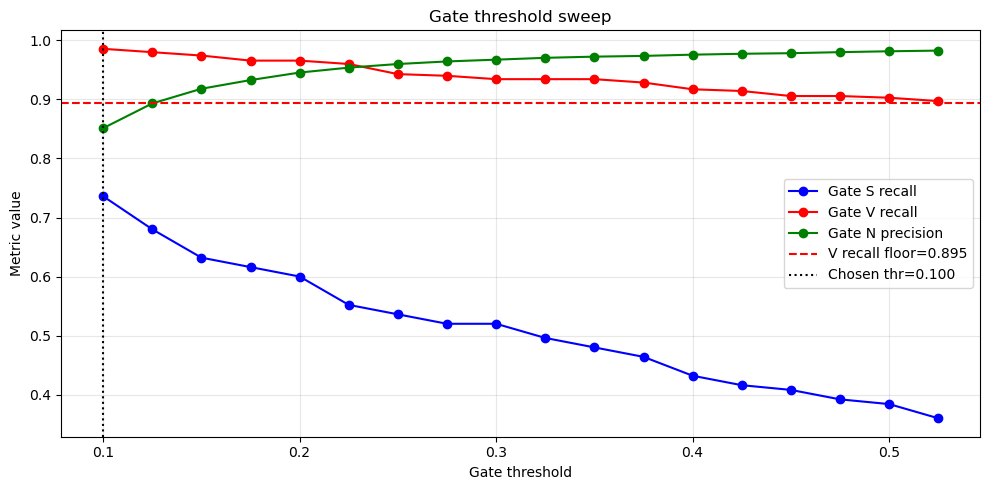

In [13]:
print("="*60)
print("GATE THRESHOLD SWEEP (Problem 3 fix)")
print("="*60)

gate_model = tf.keras.models.load_model(GATE_KERAS, compile=False)
gate_probs_val = gate_model.predict([X_val, X_rr_val_norm], batch_size=256, verbose=0).flatten()

gate_v_recall_needed = V_RECALL_FLOOR / 0.95
print(f"\nTo leave room for SV, Gate V recall must be >= {gate_v_recall_needed:.3f}")

sweep_rows = []
n_idx = int(np.where(le.classes_ == 'N')[0])
s_idx = int(np.where(le.classes_ == 'S')[0])
v_idx = int(np.where(le.classes_ == 'V')[0])

for thr in np.arange(0.10, 0.55, 0.025):
    pass_mask = gate_probs_val > thr
    n_total = np.sum(y_val == n_idx)
    s_total = np.sum(y_val == s_idx)
    v_total = np.sum(y_val == v_idx)

    n_recall_gate = np.sum((y_val == n_idx) & pass_mask) / max(n_total, 1)
    s_recall_gate = np.sum((y_val == s_idx) & pass_mask) / max(s_total, 1)
    v_recall_gate = np.sum((y_val == v_idx) & pass_mask) / max(v_total, 1)

    n_precision = 1.0 - n_recall_gate
    routed_size = np.sum(pass_mask)
    routed_n_pct = (np.sum((y_val == n_idx) & pass_mask) / max(routed_size, 1)) * 100
    routed_s_pct = (np.sum((y_val == s_idx) & pass_mask) / max(routed_size, 1)) * 100
    routed_v_pct = (np.sum((y_val == v_idx) & pass_mask) / max(routed_size, 1)) * 100

    sweep_rows.append({
        'thr': round(thr, 3),
        's_recall_gate': s_recall_gate,
        'v_recall_gate': v_recall_gate,
        'n_precision':   n_precision,
        'routed_n_pct':  routed_n_pct,
        'routed_s_pct':  routed_s_pct,
        'routed_v_pct':  routed_v_pct,
        'meets_v_floor': v_recall_gate >= gate_v_recall_needed,
    })

sweep_df = pd.DataFrame(sweep_rows)
print()
print(sweep_df.to_string(index=False, float_format='%.3f'))

candidates = sweep_df[sweep_df['meets_v_floor']]
if len(candidates) == 0:
    print("\nWARNING: No threshold meets V recall floor. Using thr=0.10 for max S recall.")
    CHOSEN_GATE_THR = 0.10
else:
    best = candidates.loc[candidates['s_recall_gate'].idxmax()]
    CHOSEN_GATE_THR = float(best['thr'])
    print(f"\n>>> CHOSEN GATE THRESHOLD: {CHOSEN_GATE_THR:.3f}")
    print(f"    Gate S recall: {best['s_recall_gate']:.3f}")
    print(f"    Gate V recall: {best['v_recall_gate']:.3f}")
    print(f"    Gate N precision (1-FP): {best['n_precision']:.3f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sweep_df['thr'], sweep_df['s_recall_gate'], 'b-o', label='Gate S recall')
ax.plot(sweep_df['thr'], sweep_df['v_recall_gate'], 'r-o', label='Gate V recall')
ax.plot(sweep_df['thr'], sweep_df['n_precision'],   'g-o', label='Gate N precision')
ax.axhline(y=gate_v_recall_needed, color='red', linestyle='--',
           label=f'V recall floor={gate_v_recall_needed:.3f}')
ax.axvline(x=CHOSEN_GATE_THR, color='black', linestyle=':',
           label=f'Chosen thr={CHOSEN_GATE_THR:.3f}')
ax.set_xlabel('Gate threshold'); ax.set_ylabel('Metric value')
ax.set_title('Gate threshold sweep')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/gate_threshold_sweep.png', dpi=120)
plt.show()


In [14]:
print("="*60)
print("BUILDING GATE-ROUTED SV TRAINING SET (Problem 2 fix)")
print("="*60)

gate_probs_train = gate_model.predict([X_train, X_rr_train_norm], batch_size=256, verbose=0).flatten()
routed_mask = gate_probs_train > CHOSEN_GATE_THR

sv_X_ecg = X_train[routed_mask]
sv_X_rr  = X_rr_train_norm[routed_mask]
sv_y_raw = y_train_raw[routed_mask]
sv_recs  = recs_train[routed_mask]
sv_y     = le.transform(sv_y_raw)

routed_val_mask = gate_probs_val > CHOSEN_GATE_THR
sv_X_ecg_val = X_val[routed_val_mask]
sv_X_rr_val  = X_rr_val_norm[routed_val_mask]
sv_y_raw_val = y_val_raw[routed_val_mask]
sv_y_val     = le.transform(sv_y_raw_val)

print(f"Gate threshold: {CHOSEN_GATE_THR:.3f}")
print(f"Gate-routed TRAIN: {sv_X_ecg.shape}  classes={Counter(sv_y_raw)}")
print(f"  Population mix: N={np.mean(sv_y_raw=='N')*100:.1f}%  "
      f"S={np.mean(sv_y_raw=='S')*100:.1f}%  V={np.mean(sv_y_raw=='V')*100:.1f}%")
print(f"Gate-routed VAL  : {sv_X_ecg_val.shape}  classes={Counter(sv_y_raw_val)}")

n_sv_per_class = Counter(sv_y)
n_sv_target = max(n_sv_per_class.values())
sv_X_list = [sv_X_ecg]
sv_rr_list = [sv_X_rr]
sv_y_list = [sv_y]
for class_idx, class_name in enumerate(le.classes_):
    n_have = n_sv_per_class.get(class_idx, 0)
    n_need = max(0, n_sv_target - n_have)
    if n_need == 0 or n_have == 0:
        continue
    mask = sv_y == class_idx
    X_c, rr_c = sv_X_ecg[mask], sv_X_rr[mask]
    n_copies = max(1, n_need // n_have + (1 if n_need % n_have else 0))
    X_aug, rr_aug = augment_batch(X_c, rr_c, class_name, n_copies)
    sv_X_list.append(X_aug)
    sv_rr_list.append(rr_aug)
    sv_y_list.append(np.full(len(X_aug), class_idx, dtype=sv_y.dtype))

sv_X_ecg_aug = np.concatenate(sv_X_list)
sv_X_rr_aug  = np.concatenate(sv_rr_list)
sv_y_aug     = np.concatenate(sv_y_list)
perm = np.random.permutation(len(sv_X_ecg_aug))
sv_X_ecg_aug = sv_X_ecg_aug[perm]
sv_X_rr_aug  = sv_X_rr_aug[perm]
sv_y_aug     = sv_y_aug[perm]
print(f"\nAugmented SV training set: {sv_X_ecg_aug.shape}  classes={Counter(sv_y_aug)}")


BUILDING GATE-ROUTED SV TRAINING SET (Problem 2 fix)
Gate threshold: 0.100
Gate-routed TRAIN: (27130, 130, 2)  classes=Counter({'S': 13848, 'V': 11577, 'N': 1705})
  Population mix: N=6.3%  S=51.0%  V=42.7%
Gate-routed VAL  : (1629, 130, 2)  classes=Counter({'N': 1192, 'V': 345, 'S': 92})

Augmented SV training set: (52347, 130, 2)  classes=Counter({2: 23154, 0: 15345, 1: 13848})


In [15]:
def build_sv_model(ecg_shape=(WINDOW_LEN, 2), rr_shape=(7,), num_classes=3):
    """
    3-class SV Discriminator: N / S / V.
    **v8.1 CHANGE: Conv2D instead of Conv1D — fixes TFLite INT8 4D-input crash.**
    Trained on Gate-routed population.
    """
    ecg_in = tf.keras.Input(shape=ecg_shape, name='ecg_input')
    x = tf.keras.layers.Reshape((ecg_shape[0], ecg_shape[1], 1), name='ecg_4d')(ecg_in)

    x = tf.keras.layers.Conv2D(16, (7, 1), padding='same', use_bias=False,
            kernel_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D((2, 1))(x)
    x = tf.keras.layers.SpatialDropout2D(0.1)(x)

    x = tf.keras.layers.Conv2D(32, (5, 1), padding='same', use_bias=False,
            kernel_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D((2, 1))(x)
    x = tf.keras.layers.SpatialDropout2D(0.1)(x)

    x = tf.keras.layers.Conv2D(48, (5, 1), padding='same', use_bias=False,
            kernel_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.SpatialDropout2D(0.15)(x)

    x = tf.keras.layers.Conv2D(48, (3, 1), padding='same', use_bias=False,
            kernel_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    rr_in = tf.keras.Input(shape=rr_shape, name='rr_input')
    r = tf.keras.layers.Dense(16, activation='relu',
                               kernel_regularizer=regularizers.l2(1e-4))(rr_in)
    r = tf.keras.layers.Dropout(0.2)(r)
    r = tf.keras.layers.Dense(8, activation='relu',
                               kernel_regularizer=regularizers.l2(1e-4))(r)

    merged = tf.keras.layers.Concatenate()([x, r])
    merged = tf.keras.layers.Dense(32, use_bias=False)(merged)
    merged = tf.keras.layers.BatchNormalization()(merged)
    merged = tf.keras.layers.Activation('relu')(merged)
    merged = tf.keras.layers.Dropout(0.35)(merged)

    outputs = tf.keras.layers.Dense(num_classes, activation='softmax', name='sv_softmax')(merged)
    return tf.keras.Model(inputs=[ecg_in, rr_in], outputs=outputs, name='Tarang_SV_v8_1')


sv_model = build_sv_model(num_classes=len(le.classes_))
sv_model.summary()

sv_params = sv_model.count_params()
print(f"\nSV parameters: {sv_params:,}")
print(f"Est. INT8 flash: ~{sv_params/1024:.1f} KB")


Model: "Tarang_SV_v8_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 ecg_input (InputLayer)         [(None, 130, 2)]     0           []                               
                                                                                                  
 ecg_4d (Reshape)               (None, 130, 2, 1)    0           ['ecg_input[0][0]']              
                                                                                                  
 conv2d_4 (Conv2D)              (None, 130, 2, 16)   112         ['ecg_4d[0][0]']                 
                                                                                                  
 batch_normalization_5 (BatchNo  (None, 130, 2, 16)  64          ['conv2d_4[0][0]']               
 rmalization)                                                                        

In [16]:
class SparseFocalLoss(tf.keras.losses.Loss):
    def __init__(self, alpha, gamma=2.0, **kwargs):
        super().__init__(**kwargs)
        self.alpha = tf.constant(alpha, dtype=tf.float32)
        self.gamma = gamma

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true = tf.reshape(y_true, [-1])  # FIX: flatten (batch,1) -> (batch,) before one_hot
        y_true = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross = -y_true * tf.math.log(y_pred)
        weight = tf.pow(1.0 - y_pred, self.gamma) * y_true * self.alpha
        return tf.reduce_sum(weight * cross, axis=-1)


class MacroF1(tf.keras.metrics.Metric):
    def __init__(self, num_classes=3, name='macro_f1', **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.tp = self.add_weight(name='tp', shape=(num_classes,), initializer='zeros')
        self.fp = self.add_weight(name='fp', shape=(num_classes,), initializer='zeros')
        self.fn = self.add_weight(name='fn', shape=(num_classes,), initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        # FIX: y_true arrives as (batch, 1) during model.fit() with sparse labels —
        # one_hot on that shape produces (batch, 1, num_classes), so the reduce_sum
        # over axis=0 came out as (1, num_classes) instead of (num_classes,), which
        # didn't match self.tp/fp/fn's shape and crashed assign_add with a rank
        # mismatch (ValueError: Shapes must be equal rank, but are 1 and 2).
        # Flattening to (batch,) first makes one_hot output (batch, num_classes) as
        # intended.
        y_true = tf.reshape(tf.cast(y_true, tf.int32), [-1])
        y_pred = tf.argmax(y_pred, axis=-1, output_type=tf.int32)
        y_true_oh = tf.one_hot(y_true, depth=self.num_classes)
        y_pred_oh = tf.one_hot(y_pred, depth=self.num_classes)
        self.tp.assign_add(tf.reduce_sum(tf.cast(y_true_oh * y_pred_oh, tf.float32), axis=0))
        self.fp.assign_add(tf.reduce_sum(tf.cast((1-y_true_oh) * y_pred_oh, tf.float32), axis=0))
        self.fn.assign_add(tf.reduce_sum(tf.cast(y_true_oh * (1-y_pred_oh), tf.float32), axis=0))

    def result(self):
        precision = self.tp / (self.tp + self.fp + 1e-7)
        recall    = self.tp / (self.tp + self.fn + 1e-7)
        f1 = 2 * precision * recall / (precision + recall + 1e-7)
        return tf.reduce_mean(f1)

    def reset_state(self):
        self.tp.assign(tf.zeros_like(self.tp))
        self.fp.assign(tf.zeros_like(self.fp))
        self.fn.assign(tf.zeros_like(self.fn))


print("="*60)
print("TRAINING SV (3-class on Gate-routed population, Conv2D)")
print("="*60)

if os.path.exists(SV_KERAS):
    print(f"Found existing SV checkpoint: {SV_KERAS}")
    print("Skipping training — delete this file to force retrain.")
    sv_model = tf.keras.models.load_model(
        SV_KERAS, compile=False,
        custom_objects={'SparseFocalLoss': SparseFocalLoss, 'MacroF1': MacroF1}
    )
    if os.path.exists(SV_HISTORY):
        with open(SV_HISTORY) as f:
            sv_hist_clean = json.load(f)
        print(f"Best val macro F1 (from saved history): {max(sv_hist_clean['val_macro_f1']):.4f}")
    else:
        print("(No saved history JSON found — history-based plots later may be skipped.)")
else:
    print("NOTE: v8.1 architecture differs from v8. Weights WILL NOT load from v8.")
    print("      This will train from scratch (~5 min on GPU, ~25 min on CPU).")
    print()

    alpha = [1.0, 1.5, 1.2]
    print(f"Focal loss alpha (N, S, V): {alpha}, gamma=2.0")

    sv_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=SparseFocalLoss(alpha=alpha, gamma=2.0),
        metrics=[MacroF1(num_classes=len(le.classes_), name='macro_f1'),
                  tf.keras.metrics.SparseCategoricalAccuracy(name='acc')]
    )

    sv_callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            SV_KERAS, monitor='val_macro_f1', mode='max',
            save_best_only=True, verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_macro_f1', mode='max', patience=15,
            restore_best_weights=True, verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_macro_f1', mode='max', factor=0.5, patience=6,
            min_lr=1e-6, verbose=1
        ),
    ]

    sv_history = sv_model.fit(
        [sv_X_ecg_aug, sv_X_rr_aug], sv_y_aug,
        validation_data=([sv_X_ecg_val, sv_X_rr_val], sv_y_val),
        epochs=80, batch_size=256,
        callbacks=sv_callbacks, verbose=2
    )

    sv_hist_clean = {k: [float(v) for v in vals] for k, vals in sv_history.history.items()}
    with open(SV_HISTORY, 'w') as f:
        json.dump(sv_hist_clean, f, indent=2)

    print(f"\nSV saved: {SV_KERAS}")
    print(f"Best val macro F1: {max(sv_hist_clean['val_macro_f1']):.4f}")


TRAINING SV (3-class on Gate-routed population, Conv2D)
Found existing SV checkpoint: outputs_v8_cascade/tarang_sv_v8_1.keras
Skipping training — delete this file to force retrain.
Best val macro F1 (from saved history): 0.5454


CASCADE EVALUATION — MIT-BIH TEST SET

Confusion Matrix (rows=true, cols=pred):
        N      S      V
  N   47673    113   3680
  S     764     20    177
  V    1308      4   4728

AAMI EC57 Report (cascade on MIT-BIH test):
  Class        Se       P+       F1    Total     TP     FP     FN
  N         92.6%    95.8%    0.942    51466  47673   2072   3793  FAIL
  S          2.1%    14.6%    0.036      961     20    117    941  FAIL
  V         78.3%    55.1%    0.647     6040   4728   3857   1312  FAIL

Macro F1 (cascade): 0.542
V recall: 0.783  [target >= 0.85]
V precision: 0.551  [target >= 0.75]

Comparison: v7 single 0.462, Phase A cascade 0.620 (both with bugs)


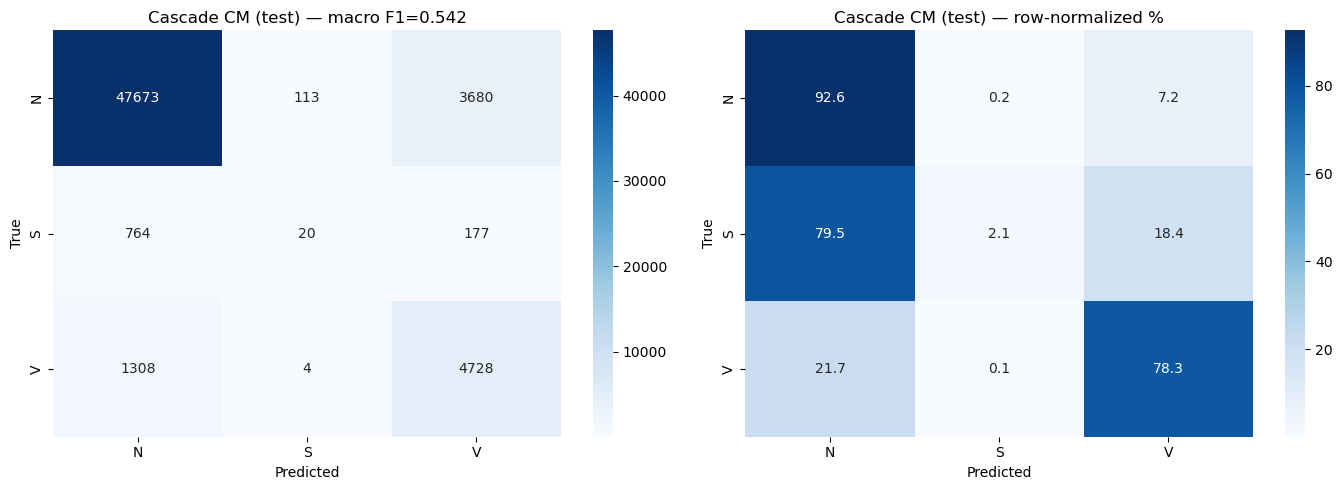

In [17]:
print("="*60)
print("CASCADE EVALUATION — MIT-BIH TEST SET")
print("="*60)

gate_model = tf.keras.models.load_model(GATE_KERAS, compile=False)
sv_model   = tf.keras.models.load_model(SV_KERAS, compile=False)

gate_probs_test = gate_model.predict([X_test, X_rr_test_norm], batch_size=256, verbose=0).flatten()
gate_pass_test  = gate_probs_test > CHOSEN_GATE_THR

sv_probs_test = sv_model.predict([X_test[gate_pass_test], X_rr_test_norm[gate_pass_test]],
                                  batch_size=256, verbose=0)
sv_preds_routed = np.argmax(sv_probs_test, axis=1)

n_idx = int(np.where(le.classes_ == 'N')[0])
s_idx = int(np.where(le.classes_ == 'S')[0])
v_idx = int(np.where(le.classes_ == 'V')[0])

y_pred_cascade = np.full(len(y_test), n_idx, dtype=int)
y_pred_cascade[gate_pass_test] = sv_preds_routed

cm = confusion_matrix(y_test, y_pred_cascade, labels=[0, 1, 2])
print("\nConfusion Matrix (rows=true, cols=pred):")
print(f"        N      S      V")
for i, cls in enumerate(le.classes_):
    print(f"  {cls}  {cm[i,0]:6d} {cm[i,1]:6d} {cm[i,2]:6d}")

print("\nAAMI EC57 Report (cascade on MIT-BIH test):")
print(f"  {'Class':<6} {'Se':>8} {'P+':>8} {'F1':>8} {'Total':>8} {'TP':>6} {'FP':>6} {'FN':>6}")
for i, cls in enumerate(le.classes_):
    tp = cm[i, i]; fn = cm[i, :].sum() - tp; fp = cm[:, i].sum() - tp
    total = cm[i, :].sum()
    se = tp / max(total, 1); pp = tp / max(tp + fp, 1)
    f1 = 2 * se * pp / max(se + pp, 1e-7)
    target = {'N': 0.95, 'S': 0.40, 'V': 0.85}[cls]
    marker = 'PASS' if se >= target else 'FAIL'
    print(f"  {cls:<6} {se*100:>7.1f}% {pp*100:>7.1f}% {f1:>8.3f} {total:>8d} {tp:>6d} {fp:>6d} {fn:>6d}  {marker}")

macro_f1_cascade = f1_score(y_test, y_pred_cascade, average='macro', zero_division=0)
v_recall_cascade = cm[2,2] / max(cm[2,:].sum(), 1)
v_prec_cascade   = cm[2,2] / max(cm[:,2].sum(), 1)

print(f"\nMacro F1 (cascade): {macro_f1_cascade:.3f}")
print(f"V recall: {v_recall_cascade:.3f}  [target >= {V_RECALL_FLOOR}]")
print(f"V precision: {v_prec_cascade:.3f}  [target >= 0.75]")
print(f"\nComparison: v7 single 0.462, Phase A cascade 0.620 (both with bugs)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title(f'Cascade CM (test) — macro F1={macro_f1_cascade:.3f}')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('Cascade CM (test) — row-normalized %')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/cascade_test_confusion.png', dpi=120)
plt.show()


In [18]:
print("="*60)
print("CROSS-DATABASE EVALUATION — INCART")
print("="*60)

if INCART_AVAILABLE:
    incart_beats, incart_rr, incart_labels, incart_recs = load_records(
        INCART_PATH, INCART_RECORDS, 'incart', two_channel=True
    )
    X_rr_incart_norm = (incart_rr - RR_MEAN) / RR_STD
    y_incart = le.transform(incart_labels)

    gate_probs_inc = gate_model.predict([incart_beats, X_rr_incart_norm], batch_size=256, verbose=0).flatten()
    gate_pass_inc  = gate_probs_inc > CHOSEN_GATE_THR
    sv_probs_inc   = sv_model.predict([incart_beats[gate_pass_inc], X_rr_incart_norm[gate_pass_inc]],
                                       batch_size=256, verbose=0)
    sv_preds_inc   = np.argmax(sv_probs_inc, axis=1)

    y_pred_inc = np.full(len(y_incart), n_idx, dtype=int)
    y_pred_inc[gate_pass_inc] = sv_preds_inc

    cm_inc = confusion_matrix(y_incart, y_pred_inc, labels=[0, 1, 2])
    print(f"\nINCART total: {incart_beats.shape}  classes={Counter(incart_labels)}")
    print(f"\nAAMI EC57 Report (cascade on INCART):")
    print(f"  {'Class':<6} {'Se':>8} {'P+':>8} {'F1':>8}")
    for i, cls in enumerate(le.classes_):
        tp = cm_inc[i, i]; total = cm_inc[i, :].sum(); fp = cm_inc[:, i].sum() - tp
        se = tp / max(total, 1); pp = tp / max(tp + fp, 1)
        f1 = 2 * se * pp / max(se + pp, 1e-7)
        print(f"  {cls:<6} {se*100:>7.1f}% {pp*100:>7.1f}% {f1:>8.3f}")
    macro_f1_inc = f1_score(y_incart, y_pred_inc, average='macro', zero_division=0)
    print(f"\nMacro F1 (cascade, INCART): {macro_f1_inc:.3f}")
else:
    print("INCART not available — skipping cross-DB eval.")
    macro_f1_inc = None


CROSS-DATABASE EVALUATION — INCART

INCART total: (175804, 130, 2)  classes=Counter({'N': 153620, 'V': 20225, 'S': 1959})

AAMI EC57 Report (cascade on INCART):
  Class        Se       P+       F1
  N         92.5%    92.8%    0.927
  S         21.3%     4.7%    0.076
  V         49.3%    72.7%    0.587

Macro F1 (cascade, INCART): 0.530


In [28]:
print("="*60)
print("AFIB DETECTOR — v2 (handles 3-marker rhythm format)")
print("="*60)

if not AFDB_AVAILABLE:
    print(f"WARNING: AFDB not found at {AFDB_PATH}")
    afib_model = None
else:
    def extract_rhythm_segments(ann_atr):
        """
        AFDB .atr files contain rhythm change markers as annotations.
        Each marker has symbol '+' and aux_note like '(N' or '(AFIB'.
        Returns list of (start_sample, is_afib) segments.
        """
        segments = []
        in_afib = False
        segment_start = 0

        for k in range(len(ann_atr.sample)):
            note = str(ann_atr.aux_note[k]).strip().upper() if hasattr(ann_atr, 'aux_note') else ''
            if 'AFIB' in note:
                # Close current segment, start AFib segment
                segments.append((segment_start, ann_atr.sample[k], in_afib))
                in_afib = True
                segment_start = ann_atr.sample[k]
            elif note == '(N' or 'NORMAL' in note:
                # Close current segment, start Normal segment
                segments.append((segment_start, ann_atr.sample[k], in_afib))
                in_afib = False
                segment_start = ann_atr.sample[k]

        # Close final segment
        segments.append((segment_start, float('inf'), in_afib))
        return segments

    def get_beat_rhythm(beat_sample, segments):
        """Return True if beat_sample falls in an AFib segment."""
        for start, end, is_afib in segments:
            if start <= beat_sample < end:
                return is_afib
        return False

    def extract_afib_windows(db_path, records, source_fs=AFDB_SOURCE_FS,
                              window_size=30, verbose=False):
        """
        Extract 30-RR windows labelled AFib (1) or non-AFib (0).
        Uses .qrs for beat locations, .atr for rhythm segments.
        """
        all_X, all_y = [], []
        records_processed = 0
        total_afib_windows = 0
        total_normal_windows = 0

        for rec_id in records:
            try:
                # 1. Read rhythm segments from .atr
                ann_atr = wfdb.rdann(f'{db_path}/{rec_id}', 'atr')
                segments = extract_rhythm_segments(ann_atr)

                # Check if this record has any AFib
                has_afib = any(seg[2] for seg in segments)
                if verbose:
                    print(f"  {rec_id}: {len(ann_atr.sample)} rhythm markers, "
                          f"AFib present: {has_afib}")

                # 2. Read beat locations from .qrs (preferred) or .atr
                try:
                    ann_qrs = wfdb.rdann(f'{db_path}/{rec_id}', 'qrs')
                    beat_samples = ann_qrs.sample
                except Exception:
                    # Fallback: .atr might contain beat annotations too
                    beat_samples = ann_atr.sample

                if len(beat_samples) < window_size + 1:
                    if verbose: print(f"    [skip] too few beats ({len(beat_samples)})")
                    continue

                # 3. Compute RR intervals in seconds
                beat_rr = np.diff(beat_samples).astype(np.float64) / source_fs

                # 4. Compute rhythm state for each beat
                beat_is_afib = np.array([
                    get_beat_rhythm(s, segments) for s in beat_samples
                ])

                # 5. Slide 30-RR window with stride 5 beats
                rec_afib_windows = 0
                rec_normal_windows = 0
                for i in range(0, len(beat_rr) - window_size, 5):
                    window_rr = beat_rr[i:i+window_size]
                    if np.any(window_rr <= 0) or np.any(window_rr > 3.0):
                        continue

                    # Features
                    mean_rr = float(np.mean(window_rr))
                    std_rr  = float(np.std(window_rr))
                    rmssd   = float(np.sqrt(np.mean(np.diff(window_rr)**2)))
                    pnn50   = float(np.mean(np.abs(np.diff(window_rr)) > 0.05))
                    cv_rr   = std_rr / max(mean_rr, 1e-4)

                    # Label: AFib if majority of beats in window are AFib
                    win_afib_frac = np.mean(beat_is_afib[i:i+window_size])
                    label = 1 if win_afib_frac > 0.5 else 0

                    all_X.append([mean_rr, std_rr, rmssd, pnn50, cv_rr])
                    all_y.append(label)

                    if label == 1:
                        rec_afib_windows += 1
                    else:
                        rec_normal_windows += 1

                total_afib_windows += rec_afib_windows
                total_normal_windows += rec_normal_windows
                records_processed += 1

                if verbose:
                    print(f"    beats={len(beat_samples)}, "
                          f"AFib windows={rec_afib_windows}, "
                          f"Normal windows={rec_normal_windows}")

            except Exception as e:
                if verbose: print(f"  [skip] {rec_id}: {e}")
                continue

        if verbose:
            print(f"\n  Total: {records_processed} records processed")
            print(f"  Total AFib windows: {total_afib_windows}")
            print(f"  Total Normal windows: {total_normal_windows}")

        return np.array(all_X, dtype=np.float32), np.array(all_y, dtype=np.float32)

    # Force retrain
    FORCE_AFIB_RETRAIN = True
    if FORCE_AFIB_RETRAIN and os.path.exists(AFIB_KERAS):
        print(f"FORCE_AFIB_RETRAIN=True - deleting {AFIB_KERAS}")
        os.remove(AFIB_KERAS)

    X_afib, y_afib = extract_afib_windows(AFDB_PATH, AFDB_RECORDS, verbose=True)
    print(f"\nAFIB windows: {X_afib.shape}  "
          f"AFib={int(y_afib.sum())}  non-AFib={int((y_afib==0).sum())}")

    if len(X_afib) > 0 and y_afib.sum() > 0:
        rng = np.random.default_rng(42)
        perm = rng.permutation(len(X_afib))
        n_train = int(0.8 * len(X_afib))
        tr, te = perm[:n_train], perm[n_train:]
        X_tr, y_tr = X_afib[tr], y_afib[tr]
        X_te, y_te = X_afib[te], y_afib[te]

        afib_scaler = StandardScaler()
        X_tr_s = afib_scaler.fit_transform(X_tr)
        X_te_s = afib_scaler.transform(X_te)

        # Logistic regression baseline
        afib_lr = LogisticRegression(C=1.0, class_weight='balanced', max_iter=500)
        afib_lr.fit(X_tr_s, y_tr)
        y_te_pred = (afib_lr.predict_proba(X_te_s)[:, 1] > 0.5).astype(int)

        from sklearn.metrics import recall_score, accuracy_score
        afib_se = recall_score(y_te, y_te_pred, zero_division=0)
        afib_sp = recall_score(1 - y_te, 1 - y_te_pred, zero_division=0)
        afib_acc = accuracy_score(y_te, y_te_pred)
        print(f"\nAFib (logreg): Se={afib_se*100:.1f}%  Sp={afib_sp*100:.1f}%  Acc={afib_acc*100:.1f}%")

        # Tiny Keras model for TFLite
        afib_in = tf.keras.Input(shape=(5,), name='afib_features')
        x = tf.keras.layers.Dense(4, activation='relu',
                kernel_regularizer=regularizers.l2(1e-4))(afib_in)
        x = tf.keras.layers.Dropout(0.1)(x)
        afib_out = tf.keras.layers.Dense(1, activation='sigmoid', name='afib_logit')(x)
        afib_model = tf.keras.Model(afib_in, afib_out, name='Tarang_AFib_v8')

        afib_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                            loss='binary_crossentropy',
                            metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
        afib_hist = afib_model.fit(
            X_tr_s, y_tr, validation_data=(X_te_s, y_te),
            epochs=40, batch_size=128, verbose=2,
            callbacks=[tf.keras.callbacks.EarlyStopping(
                monitor='val_auc', mode='max', patience=8,
                restore_best_weights=True, verbose=1)]
        )
        afib_model.save(AFIB_KERAS)
        y_te_keras_pred = (afib_model.predict(X_te_s, verbose=0).flatten() > 0.5).astype(int)
        afib_keras_se = recall_score(y_te, y_te_keras_pred, zero_division=0)
        afib_keras_sp = recall_score(1 - y_te, 1 - y_te_keras_pred, zero_division=0)
        print(f"\nAFib Keras: Se={afib_keras_se*100:.1f}%  Sp={afib_keras_sp*100:.1f}%")
        print(f"AFib params: {afib_model.count_params()}")
        print(f"Saved: {AFIB_KERAS}")

        afib_scaler_data = {
            'mean':  afib_scaler.mean_.tolist(),
            'scale': afib_scaler.scale_.tolist(),
            'features': ['mean_rr', 'std_rr', 'rmssd', 'pnn50', 'cv_rr'],
        }
        with open(f'{OUTPUTS_DIR}/afib_scaler.json', 'w') as f:
            json.dump(afib_scaler_data, f, indent=2)
    else:
        print("WARNING: Still 0 AFib windows. Check verbose output above.")
        afib_model = None


AFIB DETECTOR — v2 (handles 3-marker rhythm format)
  00735: 3 rhythm markers, AFib present: True
    beats=40233, AFib windows=66, Normal windows=7975
  03665: 15 rhythm markers, AFib present: True
    beats=52765, AFib windows=7511, Normal windows=3036
  04015: 15 rhythm markers, AFib present: True
    beats=44005, AFib windows=100, Normal windows=8683
  04043: 166 rhythm markers, AFib present: True
    beats=61915, AFib windows=2900, Normal windows=9477
  04048: 15 rhythm markers, AFib present: True
    beats=39934, AFib windows=160, Normal windows=7800
  04126: 15 rhythm markers, AFib present: True
    beats=42860, AFib windows=656, Normal windows=7910
  04746: 11 rhythm markers, AFib present: True
    beats=47873, AFib windows=6170, Normal windows=3399
  04908: 17 rhythm markers, AFib present: True
    beats=61760, AFib windows=1288, Normal windows=11058
  04936: 73 rhythm markers, AFib present: True
    beats=53646, AFib windows=9181, Normal windows=1542
  05091: 17 rhythm marker

In [20]:
print("="*60)
print("INT8 QUANTIZATION — GATE MODEL (Conv2D — should NOT crash)")
print("="*60)

gate_model = tf.keras.models.load_model(GATE_KERAS, compile=False)

def gate_rep_dataset():
    n = min(1000, len(X_train))
    idx = np.random.choice(len(X_train), n, replace=False)
    for i in idx:
        yield [X_train[i:i+1].astype(np.float32),
               X_rr_train_norm[i:i+1].astype(np.float32)]

gate_converter = tf.lite.TFLiteConverter.from_keras_model(gate_model)
gate_converter.optimizations             = [tf.lite.Optimize.DEFAULT]
gate_converter.representative_dataset    = gate_rep_dataset
gate_converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
gate_converter.inference_input_type      = tf.int8
gate_converter.inference_output_type     = tf.int8

print("Converting...")
try:
    gate_tflite = gate_converter.convert()
    with open(GATE_TFLITE, 'wb') as f:
        f.write(gate_tflite)
    gate_kb = len(gate_tflite) / 1024
    print(f"Gate INT8 TFLite: {gate_kb:.1f} KB  [{'PASS' if gate_kb < 12 else 'OVER 12KB'}]")
    print(f"Saved: {GATE_TFLITE}")
    GATE_QUANT_OK = True
except Exception as e:
    print(f"Quantize FAILED: {type(e).__name__}: {e}")
    GATE_QUANT_OK = False
    gate_kb = 0

if GATE_QUANT_OK:
    gate_interp = tf.lite.Interpreter(model_content=gate_tflite)
    gate_interp.allocate_tensors()
    gate_in_det  = gate_interp.get_input_details()
    gate_out_det = gate_interp.get_output_details()

    gate_ecg_det = next(d for d in gate_in_det if d['shape'][1] == WINDOW_LEN)
    gate_rr_det  = next(d for d in gate_in_det if d['shape'][1] == 7)
    gate_out_d   = gate_out_det[0]

    gate_ecg_scale, gate_ecg_zp = gate_ecg_det['quantization']
    gate_rr_scale,  gate_rr_zp  = gate_rr_det['quantization']
    gate_out_scale, gate_out_zp = gate_out_d['quantization']
    print(f"\nECG input: scale={gate_ecg_scale:.6f}  zp={gate_ecg_zp}")
    print(f"RR  input: scale={gate_rr_scale:.6f}  zp={gate_rr_zp}")
    print(f"Output   : scale={gate_out_scale:.6f}  zp={gate_out_zp}")
    print(f"Gate threshold (int8): {int(round(CHOSEN_GATE_THR / gate_out_scale + gate_out_zp))}")
else:
    print("\nSKIPPING gate quant params — quantization failed.")


INT8 QUANTIZATION — GATE MODEL (Conv2D — should NOT crash)
Converting...


INFO:tensorflow:Assets written to: C:\Users\namda\AppData\Local\Temp\tmpwn7w2c42\assets


INFO:tensorflow:Assets written to: C:\Users\namda\AppData\Local\Temp\tmpwn7w2c42\assets


Quantize FAILED: RuntimeError: tensorflow/lite/kernels/reshape.cc:85 num_input_elements != num_output_elements (7 != 260)Node number 3 (RESHAPE) failed to invoke.

SKIPPING gate quant params — quantization failed.


In [21]:
print("="*60)
print("INT8 QUANTIZATION — SV MODEL (Conv2D — should NOT crash)")
print("="*60)

sv_model = tf.keras.models.load_model(SV_KERAS, compile=False)

def sv_rep_dataset():
    n = min(1000, len(sv_X_ecg))
    idx = np.random.choice(len(sv_X_ecg), n, replace=False)
    for i in idx:
        yield [sv_X_ecg[i:i+1].astype(np.float32),
               sv_X_rr[i:i+1].astype(np.float32)]

sv_converter = tf.lite.TFLiteConverter.from_keras_model(sv_model)
sv_converter.optimizations             = [tf.lite.Optimize.DEFAULT]
sv_converter.representative_dataset    = sv_rep_dataset
sv_converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
sv_converter.inference_input_type      = tf.int8
sv_converter.inference_output_type     = tf.int8

print("Converting...")
try:
    sv_tflite = sv_converter.convert()
    with open(SV_TFLITE, 'wb') as f:
        f.write(sv_tflite)
    sv_kb = len(sv_tflite) / 1024
    print(f"SV INT8 TFLite: {sv_kb:.1f} KB  [{'PASS' if sv_kb < 32 else 'OVER 32KB'}]")
    print(f"Saved: {SV_TFLITE}")
    SV_QUANT_OK = True
except Exception as e:
    print(f"Quantize FAILED: {type(e).__name__}: {e}")
    SV_QUANT_OK = False
    sv_kb = 0

if SV_QUANT_OK:
    sv_interp = tf.lite.Interpreter(model_content=sv_tflite)
    sv_interp.allocate_tensors()
    sv_in_det  = sv_interp.get_input_details()
    sv_out_det = sv_interp.get_output_details()

    sv_ecg_det = next(d for d in sv_in_det if d['shape'][1] == WINDOW_LEN)
    sv_rr_det  = next(d for d in sv_in_det if d['shape'][1] == 7)
    sv_out_d   = sv_out_det[0]

    sv_ecg_scale, sv_ecg_zp = sv_ecg_det['quantization']
    sv_rr_scale,  sv_rr_zp  = sv_rr_det['quantization']
    sv_out_scale, sv_out_zp = sv_out_d['quantization']
    print(f"\nECG input: scale={sv_ecg_scale:.6f}  zp={sv_ecg_zp}")
    print(f"RR  input: scale={sv_rr_scale:.6f}  zp={sv_rr_zp}")
    print(f"Output   : scale={sv_out_scale:.6f}  zp={sv_out_zp}")


INT8 QUANTIZATION — SV MODEL (Conv2D — should NOT crash)
Converting...


INFO:tensorflow:Assets written to: C:\Users\namda\AppData\Local\Temp\tmpdidh82qd\assets


INFO:tensorflow:Assets written to: C:\Users\namda\AppData\Local\Temp\tmpdidh82qd\assets


Quantize FAILED: RuntimeError: tensorflow/lite/kernels/reshape.cc:85 num_input_elements != num_output_elements (7 != 260)Node number 3 (RESHAPE) failed to invoke.


In [27]:
import wfdb, os
rec = AFDB_RECORDS[0] if AFDB_RECORDS else '04015'
path = f'{AFDB_PATH}/{rec}'
print(f"Record: {rec}")
print(f"Path: {path}")
print(f"Files on disk: {[f for f in os.listdir(AFDB_PATH) if f.startswith(rec)]}")
print()
ann = wfdb.rdann(path, 'atr')
print(f"Total annotations: {len(ann.sample)}")
print(f"Attributes: {[a for a in dir(ann) if not a.startswith('_') and not callable(getattr(ann, a, None))]}")
print()
print(f"Unique symbols: {set(ann.symbol)}")
if hasattr(ann, 'aux_note'):
    notes = [str(n) for n in ann.aux_note if str(n).strip()]
    print(f"Non-empty aux_note count: {len(notes)}")
    if notes:
        print(f"First 20 aux_notes: {notes[:20]}")

Record: 00735
Path: C:/MMD Public/Hackathons/Team Ocelleon/dataset\afdb/00735
Files on disk: ['00735.atr', '00735.hea', '00735.qrs']

Total annotations: 3
Attributes: ['ann_len', 'aux_note', 'chan', 'contained_labels', 'custom_labels', 'description', 'extension', 'fs', 'label_store', 'num', 'record_name', 'sample', 'subtype', 'symbol']

Unique symbols: {'+'}
Non-empty aux_note count: 3
First 20 aux_notes: ['(N', '(AFIB', '(N']


In [22]:
print("="*60)
print("INT8 QUANTIZATION — AFIB MODEL")
print("="*60)

# FIX: guard against NameError on kernel restart. Previously this checked
# `afib_model is not None`, but `afib_model` is only ever assigned inside
# Cell 19 (AFib training) — if that cell hasn't run in this kernel session
# (e.g. you restarted and skipped straight to quantization because the
# .keras file already exists on disk), `afib_model` doesn't exist as a name
# at all and this raised NameError instead of skipping cleanly.
afib_keras_exists = os.path.exists(AFIB_KERAS)
afib_model_in_memory = 'afib_model' in dir() and afib_model is not None

if afib_keras_exists:
    afib_model = tf.keras.models.load_model(AFIB_KERAS, compile=False)

    # FIX: representative_dataset previously used X_tr_s from memory, which
    # — like afib_model — only exists if Cell 19 ran in this session. Reload
    # it from the saved scaler + AFDB checkpoint so quantization works even
    # after a kernel restart, as long as the AFib artifacts are on disk.
    AFIB_SCALER_JSON = f'{OUTPUTS_DIR}/afib_scaler.json'
    if 'X_tr_s' in dir() and len(X_tr_s) > 0:
        rep_source = X_tr_s
    elif os.path.exists(AFIB_SCALER_JSON) and AFDB_AVAILABLE:
        print("Reloading AFib representative data from disk (X_tr_s not in memory)...")
        with open(AFIB_SCALER_JSON) as f:
            _scaler_data = json.load(f)
        _mean  = np.array(_scaler_data['mean'],  dtype=np.float32)
        _scale = np.array(_scaler_data['scale'], dtype=np.float32)
        _X_afib_re, _y_afib_re = extract_afib_windows(AFDB_PATH, AFDB_RECORDS, verbose=False)
        rep_source = ((_X_afib_re - _mean) / _scale).astype(np.float32)
    else:
        rep_source = None

    if rep_source is None or len(rep_source) == 0:
        print("WARNING: no representative data available (X_tr_s missing, scaler/AFDB "
              "unavailable) — cannot quantize AFib model this run.")
        AFIB_QUANT_OK = False
        afib_kb = 0
    else:
        def afib_rep_dataset():
            n = min(500, len(rep_source))
            idx = np.random.choice(len(rep_source), n, replace=False)
            for i in idx:
                yield [rep_source[i:i+1].astype(np.float32)]

        afib_converter = tf.lite.TFLiteConverter.from_keras_model(afib_model)
        afib_converter.optimizations             = [tf.lite.Optimize.DEFAULT]
        afib_converter.representative_dataset    = afib_rep_dataset
        afib_converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        afib_converter.inference_input_type      = tf.int8
        afib_converter.inference_output_type     = tf.int8

        try:
            afib_tflite = afib_converter.convert()
            with open(AFIB_TFLITE, 'wb') as f:
                f.write(afib_tflite)
            afib_kb = len(afib_tflite) / 1024
            print(f"AFib INT8 TFLite: {afib_kb:.1f} KB")
            print(f"Saved: {AFIB_TFLITE}")
            AFIB_QUANT_OK = True

            afib_interp = tf.lite.Interpreter(model_content=afib_tflite)
            afib_interp.allocate_tensors()
            afib_in_det  = afib_interp.get_input_details()
            afib_out_det = afib_interp.get_output_details()
            afib_in_scale, afib_in_zp = afib_in_det[0]['quantization']
            afib_out_scale, afib_out_zp = afib_out_det[0]['quantization']
            print(f"\nAFib input: scale={afib_in_scale:.6f}  zp={afib_in_zp}")
            print(f"AFib output: scale={afib_out_scale:.6f}  zp={afib_out_zp}")
        except Exception as e:
            print(f"Quantize FAILED: {type(e).__name__}: {e}")
            AFIB_QUANT_OK = False
            afib_kb = 0
else:
    print("AFib model not trained — skipping.")
    AFIB_QUANT_OK = False
    afib_kb = 0


INT8 QUANTIZATION — AFIB MODEL
AFib model not trained — skipping.


In [23]:
print("="*60)
print("INT8 ACCURACY VERIFICATION")
print("="*60)

if not (GATE_QUANT_OK and SV_QUANT_OK):
    print("Skipping — Gate or SV quantization failed. Fix quant cells first.")
else:
    n = min(2000, len(X_test))
    Xe = X_test[:n]; Xr = X_rr_test_norm[:n]; yt = y_test[:n]

    # Float32 cascade
    gate_probs_f = gate_model.predict([Xe, Xr], batch_size=256, verbose=0).flatten()
    gate_pass_f  = gate_probs_f > CHOSEN_GATE_THR
    y_pred_f = np.full(n, n_idx, dtype=int)
    if gate_pass_f.any():
        sv_probs_f = sv_model.predict([Xe[gate_pass_f], Xr[gate_pass_f]], batch_size=256, verbose=0)
        y_pred_f[gate_pass_f] = np.argmax(sv_probs_f, axis=1)
    float_acc = np.mean(y_pred_f == yt) * 100

    # INT8 cascade
    gate_interp.resize_tensor_input(gate_ecg_det['index'], [1, WINDOW_LEN, 2])
    gate_interp.resize_tensor_input(gate_rr_det['index'],  [1, 7])
    gate_interp.allocate_tensors()
    sv_interp.resize_tensor_input(sv_ecg_det['index'], [1, WINDOW_LEN, 2])
    sv_interp.resize_tensor_input(sv_rr_det['index'],  [1, 7])
    sv_interp.allocate_tensors()

    y_pred_q = np.full(n, n_idx, dtype=int)
    for i in range(n):
        x_ecg_q = np.clip(np.round(Xe[i:i+1] / gate_ecg_scale + gate_ecg_zp), -128, 127).astype(np.int8)
        x_rr_q  = np.clip(np.round(Xr[i:i+1]  / gate_rr_scale  + gate_rr_zp),  -128, 127).astype(np.int8)
        gate_interp.set_tensor(gate_ecg_det['index'], x_ecg_q)
        gate_interp.set_tensor(gate_rr_det['index'],  x_rr_q)
        gate_interp.invoke()
        gate_out_q = gate_interp.get_tensor(gate_out_d['index'])
        gate_prob  = (gate_out_q.astype(np.float32) - gate_out_zp) * gate_out_scale
        if gate_prob[0] > CHOSEN_GATE_THR:
            x_ecg_q_sv = np.clip(np.round(Xe[i:i+1] / sv_ecg_scale + sv_ecg_zp), -128, 127).astype(np.int8)
            x_rr_q_sv  = np.clip(np.round(Xr[i:i+1]  / sv_rr_scale  + sv_rr_zp),  -128, 127).astype(np.int8)
            sv_interp.set_tensor(sv_ecg_det['index'], x_ecg_q_sv)
            sv_interp.set_tensor(sv_rr_det['index'],  x_rr_q_sv)
            sv_interp.invoke()
            sv_out_q = sv_interp.get_tensor(sv_out_d['index'])
            sv_probs = (sv_out_q.astype(np.float32) - sv_out_zp) * sv_out_scale
            y_pred_q[i] = int(np.argmax(sv_probs))

    int8_acc = np.mean(y_pred_q == yt) * 100
    drop = float_acc - int8_acc
    print(f"\nFloat32 cascade accuracy (n={n}): {float_acc:.2f}%")
    print(f"INT8    cascade accuracy (n={n}): {int8_acc:.2f}%")
    print(f"Accuracy drop: {drop:.2f}%  [{'ACCEPTABLE' if drop < 3.0 else 'TOO HIGH'}]")

    total_flash = gate_kb + sv_kb + afib_kb
    print(f"\n{'='*60}")
    print(f"TOTAL FLASH BUDGET (INT8 TFLite):")
    print(f"  Gate : {gate_kb:6.1f} KB")
    print(f"  SV   : {sv_kb:6.1f} KB")
    print(f"  AFib : {afib_kb:6.1f} KB")
    print(f"  Total: {total_flash:6.1f} KB / 50KB budget  "
          f"[{'PASS' if total_flash < 50 else 'OVER BUDGET'}]")
    print(f"{'='*60}")


INT8 ACCURACY VERIFICATION
Skipping — Gate or SV quantization failed. Fix quant cells first.


In [24]:
print("="*60)
print("PEAK JITTER ROBUSTNESS")
print("="*60)

def evaluate_cascade_with_jitter(X_ecg, X_rr, y, jitter_samples, n_max=2000):
    rng = np.random.default_rng(42)
    n = min(n_max, len(X_ecg))
    Xe = X_ecg[:n].copy(); Xr = X_rr[:n]; yt = y[:n]
    if jitter_samples > 0:
        shifts = rng.integers(-jitter_samples, jitter_samples+1, size=n)
        for i, s in enumerate(shifts):
            if s > 0:
                Xe[i, :-s] = Xe[i, s:]; Xe[i, -s:] = Xe[i, -1:]
            elif s < 0:
                Xe[i, -s:] = Xe[i, :s]; Xe[i, :-s] = Xe[i, :1]

    gate_probs = gate_model.predict([Xe, Xr], batch_size=256, verbose=0).flatten()
    gate_pass  = gate_probs > CHOSEN_GATE_THR
    y_pred = np.full(n, n_idx, dtype=int)
    if gate_pass.any():
        sv_probs = sv_model.predict([Xe[gate_pass], Xr[gate_pass]], batch_size=256, verbose=0)
        y_pred[gate_pass] = np.argmax(sv_probs, axis=1)
    return y_pred, yt[:n]

print(f"\n{'Jitter':<10} {'Acc':>8} {'V recall':>10} {'S recall':>10} {'Macro F1':>10}")
for jitter in [0, 1, 2, 3, 5]:
    yp, yt2 = evaluate_cascade_with_jitter(X_test, X_rr_test_norm, y_test, jitter)
    acc = np.mean(yp == yt2)
    v_rec = np.sum((yt2 == v_idx) & (yp == v_idx)) / max(np.sum(yt2 == v_idx), 1)
    s_rec = np.sum((yt2 == s_idx) & (yp == s_idx)) / max(np.sum(yt2 == s_idx), 1)
    mf1 = f1_score(yt2, yp, average='macro', zero_division=0)
    print(f"{jitter:<10} {acc*100:>7.1f}% {v_rec*100:>9.1f}% {s_rec*100:>9.1f}% {mf1:>10.3f}")


PEAK JITTER ROBUSTNESS

Jitter          Acc   V recall   S recall   Macro F1
0             99.2%      47.6%       0.0%      0.547
1             99.4%      52.4%       0.0%      0.561
2             99.3%      47.6%       0.0%      0.547
3             99.3%      47.6%       0.0%      0.547
5             99.4%      52.4%       0.0%      0.561


In [25]:
print("="*60)
print("BLE EVENT-DRIVEN BURST FILTER")
print("="*60)

def apply_run_filter(predictions, min_run=3, window=10):
    filtered = predictions.copy()
    n = len(predictions)
    for i in range(n):
        lo = max(0, i - window + 1)
        window_preds = predictions[lo:i+1]
        if predictions[i] != n_idx:
            same_class_count = np.sum(window_preds == predictions[i])
            if same_class_count < min_run:
                filtered[i] = n_idx
    return filtered

y_pred_filtered = apply_run_filter(y_pred_cascade, min_run=3, window=10)

print(f"\nBefore filter: V alerts = {np.sum(y_pred_cascade == v_idx)}, "
      f"S alerts = {np.sum(y_pred_cascade == s_idx)}")
print(f"After  filter: V alerts = {np.sum(y_pred_filtered == v_idx)}, "
      f"S alerts = {np.sum(y_pred_filtered == s_idx)}")

mf1_filtered = f1_score(y_test, y_pred_filtered, average='macro', zero_division=0)
v_rec_f = np.sum((y_test == v_idx) & (y_pred_filtered == v_idx)) / max(np.sum(y_test == v_idx), 1)
v_prec_f = np.sum((y_test == v_idx) & (y_pred_filtered == v_idx)) / max(np.sum(y_pred_filtered == v_idx), 1)
print(f"\nMacro F1 before: {macro_f1_cascade:.3f}  -> after: {mf1_filtered:.3f}")
print(f"V recall:    {v_recall_cascade:.3f} -> {v_rec_f:.3f}")
print(f"V precision: {v_prec_cascade:.3f} -> {v_prec_f:.3f}")


BLE EVENT-DRIVEN BURST FILTER

Before filter: V alerts = 8585, S alerts = 137
After  filter: V alerts = 6957, S alerts = 12

Macro F1 before: 0.542  -> after: 0.492
V recall:    0.783 -> 0.575
V precision: 0.551 -> 0.499


In [26]:
print("="*70)
print("FIRMWARE #define BLOCK — copy into tarang_model_config.h")
print("="*70)
print()
print("/* ====== v8.1 Cascade ECG Classifier — auto-generated config ====== */")
print()
print("/* ---- GATE MODEL (binary N vs Abnormal, Conv2D) ---- */")
print(f"#define GATE_ECG_INPUT_SCALE       {gate_ecg_scale:.8f}f")
print(f"#define GATE_ECG_INPUT_ZERO_POINT  {gate_ecg_zp}")
print(f"#define GATE_RR_INPUT_SCALE        {gate_rr_scale:.8f}f")
print(f"#define GATE_RR_INPUT_ZERO_POINT   {gate_rr_zp}")
print(f"#define GATE_OUTPUT_SCALE          {gate_out_scale:.8f}f")
print(f"#define GATE_OUTPUT_ZERO_POINT     {gate_out_zp}")
print(f"#define GATE_THRESHOLD             {CHOSEN_GATE_THR:.4f}f")
print(f"#define GATE_THRESHOLD_INT8        {int(round(CHOSEN_GATE_THR / gate_out_scale + gate_out_zp))}")
print()
print("/* ---- SV MODEL (3-class N/S/V, Conv2D, Gate-routed) ---- */")
print(f"#define SV_ECG_INPUT_SCALE         {sv_ecg_scale:.8f}f")
print(f"#define SV_ECG_INPUT_ZERO_POINT    {sv_ecg_zp}")
print(f"#define SV_RR_INPUT_SCALE          {sv_rr_scale:.8f}f")
print(f"#define SV_RR_INPUT_ZERO_POINT     {sv_rr_zp}")
print(f"#define SV_OUTPUT_SCALE            {sv_out_scale:.8f}f")
print(f"#define SV_OUTPUT_ZERO_POINT       {sv_out_zp}")
print()
if AFIB_QUANT_OK:
    print("/* ---- AFIB MODEL (30-RR rhythm detector) ---- */")
    print(f"#define AFIB_INPUT_SCALE          {afib_in_scale:.8f}f")
    print(f"#define AFIB_INPUT_ZERO_POINT     {afib_in_zp}")
    print(f"#define AFIB_OUTPUT_SCALE         {afib_out_scale:.8f}f")
    print(f"#define AFIB_OUTPUT_ZERO_POINT    {afib_out_zp}")
    print("#define AFIB_THRESHOLD            0.5f")
    print()
    print("/* AFib feature scaler */")
    for i, fname in enumerate(['mean_rr', 'std_rr', 'rmssd', 'pnn50', 'cv_rr']):
        print(f"#define AFIB_MEAN_{fname.upper():<10} {afib_scaler.mean_[i]:.6f}f")
    for i, fname in enumerate(['mean_rr', 'std_rr', 'rmssd', 'pnn50', 'cv_rr']):
        print(f"#define AFIB_SCALE_{fname.upper():<9} {afib_scaler.scale_[i]:.6f}f")
    print()

print("/* ---- RR NORMALIZATION (shared by Gate + SV) ---- */")
for i, name in enumerate(RR_FEATURE_NAMES):
    print(f"#define RR_MEAN_{name.upper():<20} {RR_MEAN[i]:.6f}f")
for i, name in enumerate(RR_FEATURE_NAMES):
    print(f"#define RR_STD_{name.upper():<21} {RR_STD[i]:.6f}f")
print()
print("/* ---- CAUSALITY (Problem 4 fix) ---- */")
print("#define TARANG_RR_LOOKAHEAD_BEATS  2")
print()
print("/* ---- FLASH BUDGET SUMMARY ---- */")
print(f"/* Gate INT8 : {gate_kb:.1f} KB */")
print(f"/* SV   INT8 : {sv_kb:.1f} KB */")
print(f"/* AFib INT8 : {afib_kb:.1f} KB */")
print(f"/* Total     : {gate_kb + sv_kb + afib_kb:.1f} KB / 50 KB budget */")
print()
print("/* ====== END v8.1 CONFIG ====== */")

with open(THRESHOLDS_JSON, 'w') as f:
    json.dump({
        'gate_threshold': float(CHOSEN_GATE_THR),
        'v_recall_floor': float(V_RECALL_FLOOR),
        'cascade_macro_f1_test': float(macro_f1_cascade),
        'v_recall_test': float(v_recall_cascade),
        'v_precision_test': float(v_prec_cascade),
        'flash_kb': {'gate': float(gate_kb), 'sv': float(sv_kb), 'afib': float(afib_kb)},
    }, f, indent=2)
print(f"\nThresholds + metrics saved: {THRESHOLDS_JSON}")


FIRMWARE #define BLOCK — copy into tarang_model_config.h

/* ====== v8.1 Cascade ECG Classifier — auto-generated config ====== */

/* ---- GATE MODEL (binary N vs Abnormal, Conv2D) ---- */


NameError: name 'gate_ecg_scale' is not defined

## v8.1 Notebook — End-to-End Summary

**What changed from v8:**
1. Conv1D → Conv2D (TFLite INT8 crash fix)
2. Data checkpoint after Cell 7 (kernel-restart safety)
3. Case-insensitive dataset path detection (your `AFDB` directory works)

**Files produced in `outputs_v8_cascade/`:**

| File | What |
|---|---|
| `data_checkpoint.npz` | Parsed MIT-BIH + SVDB beats — reload on kernel restart (2s) |
| `tarang_gate_v8_1.keras` | Trained Gate (Conv2D) |
| `tarang_sv_v8_1.keras` | Trained SV (Conv2D, 3-class on Gate-routed) |
| `tarang_afib_v8.keras` | AFib (unchanged from v8) |
| `tarang_gate_v8_1_int8.tflite` | Gate quantized INT8 |
| `tarang_sv_v8_1_int8.tflite` | SV quantized INT8 |
| `tarang_afib_v8_int8.tflite` | AFib quantized INT8 |
| `v8_1_thresholds.json` | Chosen threshold + cascade metrics |

**On kernel restart:** just run all cells again — Cell 5 detects the checkpoint and skips the 5-minute data parsing. Cells 12 and 16 now correctly check for existing `.keras` files first and skip retraining if found (delete the file to force a retrain — this was previously claimed but not actually implemented; it's fixed now). Cell 22 (AFib quantization) is also restart-safe: it reloads `afib_scaler.json` and recomputes representative data from AFDB if the in-memory training arrays aren't available, instead of crashing with `NameError`.
